In [276]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,KFold,RandomizedSearchCV,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder
from sklearn.impute import SimpleImputer


In [277]:
df = pd.read_csv("/content/bigmart.csv")

In [278]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [279]:
df.groupby(["Outlet_Type","Item_Fat_Content"])["Item_Outlet_Sales"].sum()

Outlet_Type        Item_Fat_Content
Grocery Store      LF                  1.536533e+04
                   Low Fat             2.195522e+05
                   Regular             1.223860e+05
                   low fat             5.763831e+03
                   reg                 4.966868e+03
Supermarket Type1  LF                  4.334105e+05
                   Low Fat             7.661034e+06
                   Regular             4.486011e+06
                   low fat             1.630757e+05
                   reg                 1.738111e+05
Supermarket Type2  LF                  9.171395e+04
                   Low Fat             1.091234e+06
                   Regular             6.156886e+05
                   low fat             1.835744e+04
                   reg                 3.482933e+04
Supermarket Type3  LF                  1.147526e+05
                   Low Fat             2.043205e+06
                   Regular             1.233369e+06
                   low fat             4.662997e+04
                   reg                 1.596921e+04
Name: Item_Outlet_Sales, dtype: float64

In [280]:
df["Outlet_Type"].value_counts

<bound method IndexOpsMixin.value_counts of 0       Supermarket Type1
1       Supermarket Type2
2       Supermarket Type1
3           Grocery Store
4       Supermarket Type1
              ...        
8518    Supermarket Type1
8519    Supermarket Type1
8520    Supermarket Type1
8521    Supermarket Type2
8522    Supermarket Type1
Name: Outlet_Type, Length: 8523, dtype: object>

In [281]:
df.groupby(["Outlet_Type","Item_Type"])["Item_Outlet_Sales"].sum()

Outlet_Type        Item_Type    
Grocery Store      Baking Goods      24827.0162
                   Breads            12604.9256
                   Breakfast          7843.7898
                   Canned            25759.1362
                   Dairy             31451.7262
                                       ...     
Supermarket Type3  Others            40513.9300
                   Seafood           18809.5158
                   Snack Foods      513088.1172
                   Soft Drinks      147822.2476
                   Starchy Foods     49170.6616
Name: Item_Outlet_Sales, Length: 64, dtype: float64

In [282]:
df["Outlet_Identifier"].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [283]:
df.groupby(["Outlet_Identifier","Item_Type"])["Item_Outlet_Sales"].sum()

Outlet_Identifier  Item_Type    
OUT010             Baking Goods      10693.4138
                   Breads             7657.3658
                   Breakfast          4081.3540
                   Canned             9019.5926
                   Dairy             15307.4078
                                       ...     
OUT049             Others            47772.4816
                   Seafood           11827.2712
                   Snack Foods      350244.0900
                   Soft Drinks       97585.6402
                   Starchy Foods     42019.9696
Name: Item_Outlet_Sales, Length: 160, dtype: float64

In [284]:
df["Outlet_Age"] = 2026 - df["Outlet_Establishment_Year"]

In [285]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [286]:
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.median()))
df['Item_Weight'].fillna(df['Item_Weight'].median(), inplace=True)

/tmp/ipykernel_2115/236591856.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].median(), inplace=True)


In [287]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [288]:
df['Outlet_Size'] = df.groupby('Outlet_Identifier')['Outlet_Size'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))


/tmp/ipykernel_2115/3909490568.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Outlet_Size'] = df.groupby('Outlet_Identifier')['Outlet_Size'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))


In [289]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [290]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [291]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Age
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.875314,0.066132,140.992782,1997.831867,2181.288914,28.168133
std,4.645010,0.051598,62.275067,8.371760,1706.499616,8.371760
min,4.555000,0.000000,31.290000,1985.000000,33.290000,17.000000
25%,8.785000,0.026989,93.826500,1987.000000,834.247400,22.000000
50%,12.650000,0.053931,143.012800,1999.000000,1794.331000,27.000000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400,39.000000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800,41.000000


In [292]:
df.dropna()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,28
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,39
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850,24
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,22
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,17


In [293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Outlet_Age                 8523 non-null   int64  
dtypes: float64(4), int64(2), object(7)
memory usage:

In [294]:
df.drop(columns=["Outlet_Establishment_Year","Item_Identifier"])

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,17
2,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,Medium,Tier 3,Grocery Store,732.3800,28
4,8.930,Low Fat,0.000000,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,39
...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,High,Tier 3,Supermarket Type1,2778.3834,39
8519,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,Medium,Tier 2,Supermarket Type1,549.2850,24
8520,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,Small,Tier 2,Supermarket Type1,1193.1136,22
8521,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,Medium,Tier 3,Supermarket Type2,1845.5976,17


In [295]:
num_col = list(df.drop("Item_Outlet_Sales",axis=1).select_dtypes(include=["number"]).columns)
num_col

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Outlet_Age']

In [296]:
cat_col = list(df.select_dtypes(exclude=["number"]).columns)
cat_col

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [297]:
pd.get_dummies(df[cat_col])

,Item_Identifier_DRA12,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,Item_Identifier_DRB24,Item_Identifier_DRB25,Item_Identifier_DRB48,Item_Identifier_DRC01,Item_Identifier_DRC12,Item_Identifier_DRC13,Item_Identifier_DRC24,Item_Identifier_DRC25,Item_Identifier_DRC27,Item_Identifier_DRC36,Item_Identifier_DRC49,Item_Identifier_DRD01,Item_Identifier_DRD12,Item_Identifier_DRD13,Item_Identifier_DRD15,Item_Identifier_DRD24,Item_Identifier_DRD25,Item_Identifier_DRD27,Item_Identifier_DRD37,Item_Identifier_DRD49,Item_Identifier_DRD60,Item_Identifier_DRE01,Item_Identifier_DRE03,Item_Identifier_DRE12,Item_Identifier_DRE13,Item_Identifier_DRE15,Item_Identifier_DRE25,Item_Identifier_DRE27,Item_Identifier_DRE37,Item_Identifier_DRE48,Item_Identifier_DRE49,Item_Identifier_DRE60,Item_Identifier_DRF01,Item_Identifier_DRF03,Item_Identifier_DRF13,...,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,True,False,Fa

/tmp/ipykernel_2115/356991007.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Item_Outlet_Sales"])


<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

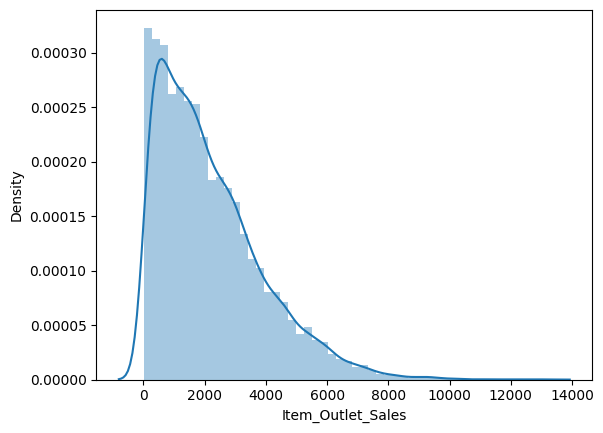

In [298]:
sns.distplot(df["Item_Outlet_Sales"])

In [315]:
df["Item_Outlet_Sales"].skew

<bound method Series.skew of 0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64>

In [299]:
df["Item_Outlet_Sales"].describe()

,Item_Outlet_Sales
count,8523.000000
mean,2181.288914
std,1706.499616
min,33.290000
25%,834.247400
50%,1794.331000
75%,3101.296400
max,13086.964800


Outliers handled for Item_Outlet_Sales.


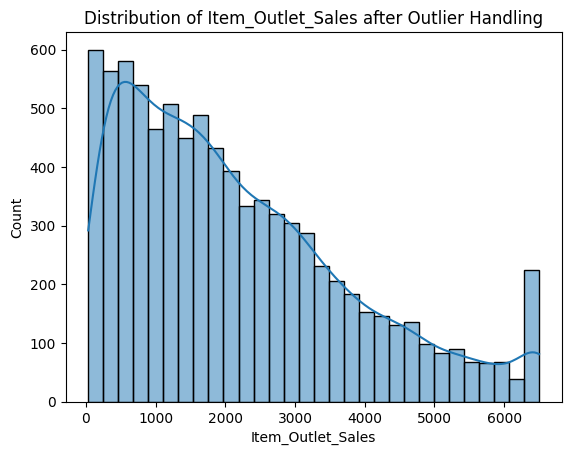

,Item_Outlet_Sales
count,8523.000000
mean,2156.313016
std,1624.863069
min,33.290000
25%,834.247400
50%,1794.331000
75%,3101.296400
max,6501.869900


In [300]:
Q1 = df['Item_Outlet_Sales'].quantile(0.25)
Q3 = df['Item_Outlet_Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['Item_Outlet_Sales'] = np.where(df['Item_Outlet_Sales'] > upper_bound, upper_bound, df['Item_Outlet_Sales'])

print("Outliers handled for Item_Outlet_Sales.")
sns.histplot(df["Item_Outlet_Sales"], kde=True)
plt.title('Distribution of Item_Outlet_Sales after Outlier Handling')
plt.show()
df["Item_Outlet_Sales"].describe()

In [301]:
X = df.drop(columns=["Item_Outlet_Sales"])
y = df["Item_Outlet_Sales"]

In [302]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.15,shuffle=True)

In [303]:
num_pipe = Pipeline([
    ("impute",SimpleImputer(strategy="mean")),
    ("scale",StandardScaler())
])
cat_pipe = Pipeline([
    ("impute",SimpleImputer(strategy="most_frequent")),
    ("Encoding",OneHotEncoder(handle_unknown="ignore"))
])

In [304]:
preprocessor = ColumnTransformer([
    ("numerical_preproceesing",num_pipe,num_col),
    ("cat_preprocessing",cat_pipe,cat_col)
])

In [305]:
from sklearn.decomposition import PCA

pipe = Pipeline([
    ("preprocess",preprocessor),
    ("pca",PCA(n_components=250)),
    ("model",SVR())
])

In [306]:
pipe.fit(X_train,y_train)
from sklearn.metrics import r2_score
r2_score(y_test,pipe.predict(X_test))

0.04703502688848271

In [307]:
grid_params = [
    {
        'model': [SVR()],
        'model__C': [0.1, 1, 10],
        'model__epsilon': [0.1, 0.2, 0.5],
        'pca__n_components': [50, 75]
    },
    {
        'model': [DecisionTreeRegressor()],
        'model__max_depth': [None, 15, 30],
        'pca__n_components': [50, 75]
    },
    {
        'model': [RandomForestRegressor()],
        'model__n_estimators': [50, 100],
        'model__max_depth': [None, 10, 20],
        'pca__n_components': [50, 75]
    },
    {
        'model': [LinearRegression()],
        'pca__n_components': [50, 75]
    }
]

In [308]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

In [309]:
grid_model = RandomizedSearchCV(pipe,
                          cv = cv,
                          n_jobs=-1,
                          return_train_score = True,
                          scoring="r2",
                          param_distributions=grid_params)

In [310]:
grid_model.fit(X_train,y_train)

RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('numerical_preproceesing',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer()),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Item_Weight',
                                                                                'Item_Visibility',
                                                                                'Item_MRP',
                                                                                'Outlet_Establishment_Year',
                                                                                'Outlet_Age']),
                                                                              ('cat_preprocessing',
                                                                               Pi...
                                         'model__epsilon': [0.1, 0.2, 0.5],
                                         'pca__n_components': [50, 75]},
                                        {'model': [DecisionTreeRegressor()],
                                         'model__max_depth': [None, 15, 30],
                                         'pca__n_components': [50, 75]},
                                        {'model': [RandomForestRegressor()],
                                         'model__max_depth': [None, 10, 20],
                                         'model__n_estimators': [50, 100],
                                         'pca__n_components': [50, 75]},
                                        {'model': [LinearRegression()],
                                         'pca__n_components': [50, 75]}],
                   return_train_score=True, scoring='r2')

In [311]:
grid_model.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_preproceesing',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Item_Weight',
                                                   'Item_Visibility',
                                                   'Item_MRP',
                                                   'Outlet_Establishment_Year',
                                                   'Outlet_Age']),
                                                 ('cat_preprocessing',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Item_Identifier',
                                                   'Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Size',
                                                   'Outlet_Location_Type',
                                                   'Outlet_Type'])])),
                ('pca', PCA(n_components=75)),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=50))])

In [312]:
y_pred = grid_model.best_estimator_.predict(X_test)

In [313]:
r2_score(y_test,y_pred)

0.5857580620918168

In [316]:
# import joblib
# joblib.dump(grid_model,"BigmartSalesPrediction")

In [317]:
grid_model.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_preproceesing',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Item_Weight',
                                                   'Item_Visibility',
                                                   'Item_MRP',
                                                   'Outlet_Establishment_Year',
                                                   'Outlet_Age']),
                                                 ('cat_preprocessing',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Item_Identifier',
                                                   'Item_Fat_Content',
                                                   'Item_Type',
                                                   'Outlet_Identifier',
                                                   'Outlet_Size',
                                                   'Outlet_Location_Type',
                                                   'Outlet_Type'])])),
                ('pca', PCA(n_components=75)),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=50))])